# **Sudan**

**Imports and Data Loading**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("sudan.csv")

df['Country'] = "Sudan"

print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} cols.")

Dataset loaded with 4108 rows and 13 cols.


**Missing Value Handling & Sentinels**

In [2]:
df.replace(~999, np.nan, inplace=True)

duplicates = df.duplicated().sum()
df.drop_duplicates(inplace=True)

null_reports = df.isna().sum()
null_percentage = (null_reports / len(df)) * 100

print(f"Duplicates removed: {duplicates}")
print("\nMissing Value Percentage per Column: ", end="")
print(null_percentage[null_percentage > 0])

Duplicates removed: 0

Missing Value Percentage per Column: Series([], dtype: float64)


**Data Parsing**

In [3]:
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

df['Month'] = df['Date'].dt.month

df.set_index('Date', inplace=True)

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-01,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,1
2015-01-02,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,1
2015-01-03,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,1
2015-01-04,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,1
2015-01-05,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,1


**Outlier Detection**

In [4]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

z_scores = np.abs(stats.zscore(df[cols_to_check].dropna()))

outliers = (z_scores > 3).sum()
print(f"Outlier counts: {outliers}")

df.ffill(inplace=True)

Outlier counts: 91


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-01,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,1
2015-01-02,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,1
2015-01-03,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,1
2015-01-04,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,1
2015-01-05,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-27,2026,86,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52,Sudan,3
2026-03-28,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,Sudan,3
2026-03-29,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,Sudan,3


**Time Series Visualization**

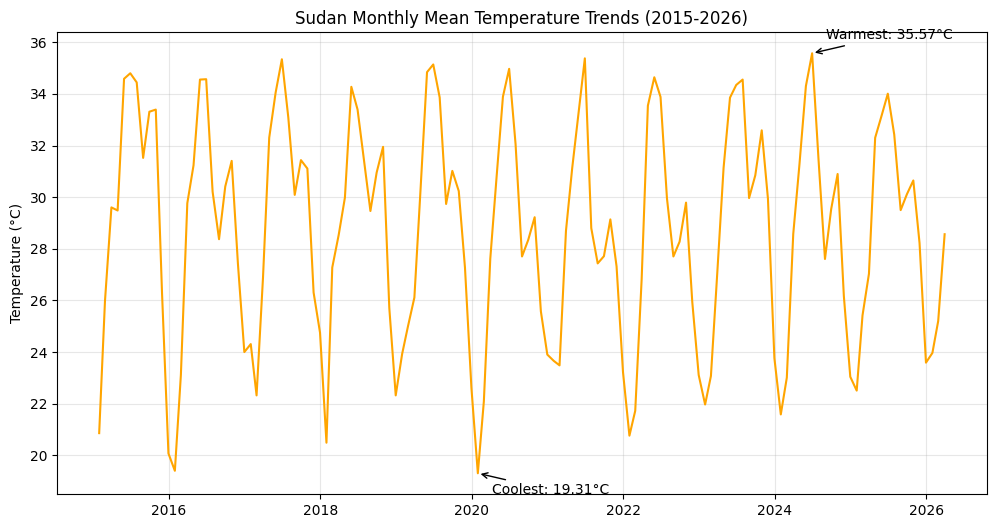

In [5]:
monthly_temps = df['T2M'].resample('ME').mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly_temps, color='orange', label='Mean Temp (T2M)')

warmest = monthly_temps.idxmax()
coolest = monthly_temps.idxmin()

plt.annotate(f'Warmest: {monthly_temps.max():.2f}°C', xy=(warmest, monthly_temps.max()), 
             xytext=(10, 10), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
plt.annotate(f'Coolest: {monthly_temps.min():.2f}°C', xy=(coolest, monthly_temps.min()), 
             xytext=(10, -15), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

plt.title('Sudan Monthly Mean Temperature Trends (2015-2026)')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

**Precipitation Analysis**

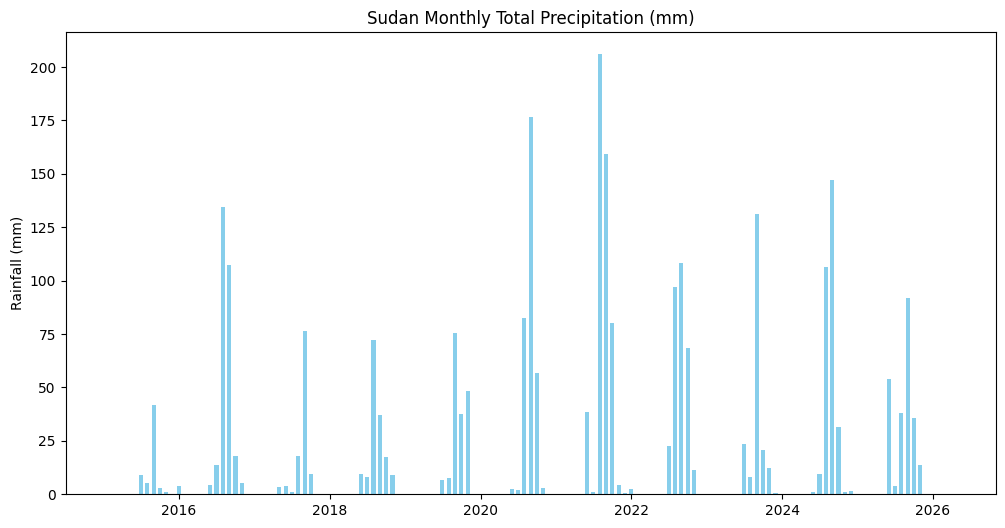

In [6]:
monthly_precip = df['PRECTOTCORR'].resample('ME').sum()

plt.figure(figsize=(12,6))
plt.bar(monthly_precip.index, monthly_precip.values, width=20, color='skyblue')
plt.title('Sudan Monthly Total Precipitation (mm)')
plt.ylabel('Rainfall (mm)')

plt.show()

**Correlation Heatmap**

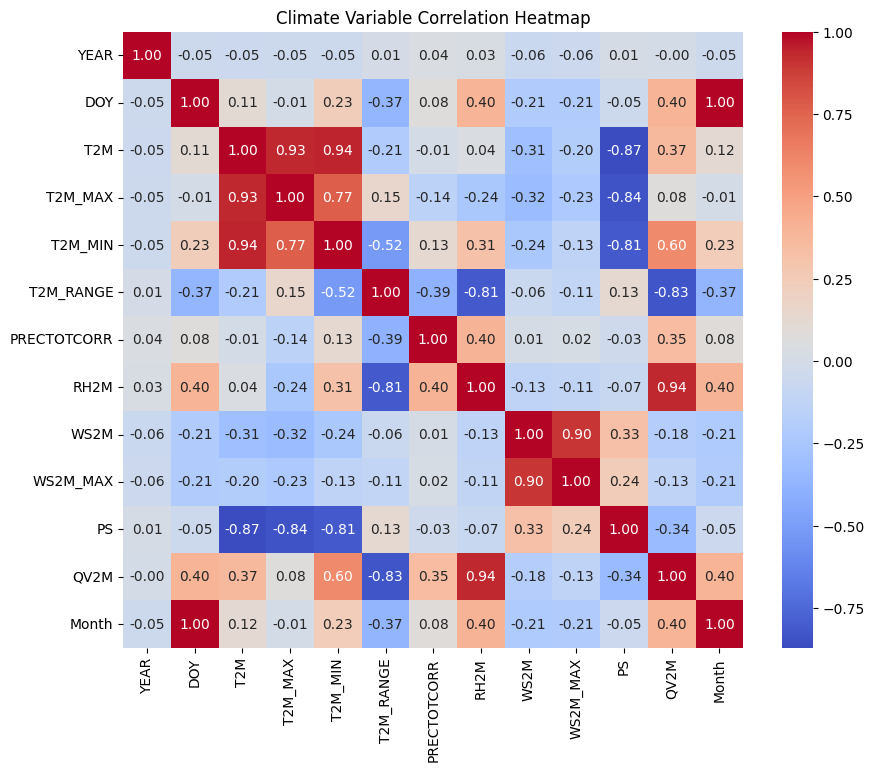

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Climate Variable Correlation Heatmap')
plt.show()

**Exporting Cleaned Data**

In [8]:
import os
if not os.path.exists('../data'):
    os.makedirs('../data')
df.to_csv("../data/sudan_clean.csv")
print("Cleaned data exported to data/sudan_clean.csv")

Cleaned data exported to data/sudan_clean.csv
